## - Modelo Random Forest

Parte complementar do projeto Final da disciplina Aprendizagem de Máquina/PPgTI

### Preparação e carga de dados

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    log_loss,
)
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import numpy as np

sns.set_style('whitegrid')

In [3]:
# carregar o dataset normalizado atualizado
data_path = Path('norm_df_metadadosPericias.csv')
if not data_path.exists():
    data_path = Path('/content/drive/norm_df_metadadosPericias.csv')

print(f'Carregando dataset normalizado de {data_path}')
df_norm = pd.read_csv(data_path)
print('Formato do dataset:', df_norm.shape)
print('\nDistribuição proporcional da variável alvo:')
print(df_norm['requer_pericia_count'].value_counts(normalize=True).rename('ratio'))
print('\nDistribuição absoluta da variável alvo:')
print(df_norm['requer_pericia_count'].value_counts())

Carregando dataset normalizado de norm_df_metadadosPericias.csv
Formato do dataset: (165498, 17)

Distribuição proporcional da variável alvo:
requer_pericia_count
1.0    0.50719
0.0    0.49281
Name: ratio, dtype: float64

Distribuição absoluta da variável alvo:
requer_pericia_count
1.0    83939
0.0    81559
Name: count, dtype: int64


In [4]:
df_norm.head()

,id_processo_judicial,in_tutela_antecipada_count,nm_juizado_count,ds_cidade_count,codigo_assunto_count,ds_assunto_judicial_count,ds_complemento_assunto_judicial_count,detalhe_assunto_1_count,detalhe_assunto_2_count,id_perito_count,ds_especialidade_count,ds_complemento_especialidade_count,ds_status_pericia_count,vara_count,triagem_peticao_count,label_especialidade_count,requer_pericia_count
0,0.974073,1.0,0.364363,0.116711,1.000000,1.000000,1.00000,1.000000,1.000000,0.004034,0.940182,0.267988,0.031846,0.123086,0.0,0.283492,1.0
1,0.512348,1.0,0.299115,0.080664,1.000000,1.000000,1.00000,0.356039,1.000000,0.009907,0.940182,0.120853,0.860855,0.087570,0.0,0.123303,1.0
2,0.178221,1.0,0.773330,0.344579,0.200864,0.200864,0.14681,0.318839,0.018163,1.000000,1.000000,1.000000,1.000000,0.349154,0.0,1.000000,0.0
3,0.576451,1.0,0.773330,0.344579,1.000000,1.000000,1.00000,1.000000,1.000000,0.034368,0.940182,0.267988,0.057866,0.349154,0.0,0.283492,1.0
4,0.697003,1.0,0.276221,0.068015,1.000000,1.000000,1.00000,1.000000,1.000000,0.010385,0.940182,0.120853,0.860855,0.074322,0.0,0.053155,1.0


### Organização de dados para treinamento, validação e testes

Nessa rodada de classificação, o objetivo é prever exclusivamente se o processo **requer perícia ou não**, usando a coluna `requer_pericia_count` como variável alvo.

As colunas `['ds_status_pericia_count', 'ds_especialidade_count', 'ds_complemento_especialidade_count', 'id_perito_count']` foram removidas das features porque podem introduzir informações que só aparecem depois da realização ou tramitação da perícia. Além delas, também foram removidas `label_especialidade_count` e `id_processo_judicial`, pois não fazem parte do objetivo principal desta etapa.

Portanto, o treinamento passa a utilizar apenas atributos disponíveis antes da definição/realização da perícia, evitando vazamento de informação.

In [5]:
# preparar os dados para treino, validação e teste
# Proporção final desejada: 70% treino, 20% validação e 10% teste

colunas_removidas = [
    'requer_pericia_count',
    'label_especialidade_count',
    'id_processo_judicial',
    'ds_status_pericia_count',
    'ds_especialidade_count',
    'ds_complemento_especialidade_count',
    'id_perito_count'
]

feature_cols = [col for col in df_norm.columns if col not in colunas_removidas]

X = df_norm[feature_cols]
y = df_norm['requer_pericia_count'].astype(int)

# Primeiro separa 10% para teste.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=42,
    shuffle=True
)

# Dos 90% restantes, separa 2/9 para validação.
# 2/9 de 90% = 20% do total, restando 70% para treino.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=2 / 9,
    stratify=y_train_val,
    random_state=42,
    shuffle=True
)

print('Features utilizadas no treinamento:')
print(feature_cols)

print('\nDivisão de dados:')
print('  treino:', X_train.shape, f'({len(X_train) / len(df_norm):.2%})')
print('  validação:', X_val.shape, f'({len(X_val) / len(df_norm):.2%})')
print('  teste:', X_test.shape, f'({len(X_test) / len(df_norm):.2%})')

Features utilizadas no treinamento:
['in_tutela_antecipada_count', 'nm_juizado_count', 'ds_cidade_count', 'codigo_assunto_count', 'ds_assunto_judicial_count', 'ds_complemento_assunto_judicial_count', 'detalhe_assunto_1_count', 'detalhe_assunto_2_count', 'vara_count', 'triagem_peticao_count']

Divisão de dados:
  treino: (115848, 10) (70.00%)
  validação: (33100, 10) (20.00%)
  teste: (16550, 10) (10.00%)


### Aplicação do Random Forest

In [6]:
# treinar o modelo Random Forest

tree_steps = [10, 50, 100, 150, 200, 250, 300]

model = RandomForestClassifier(
    n_estimators=10,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    warm_start=True,
)

learning_history = []

for n_trees in tree_steps:
    model.set_params(n_estimators=n_trees)
    model.fit(X_train, y_train)

    y_train_pred_step = model.predict(X_train)
    y_val_pred_step = model.predict(X_val)

    y_train_proba_step = model.predict_proba(X_train)
    y_val_proba_step = model.predict_proba(X_val)

    learning_history.append({
        'n_estimators': n_trees,
        'train_logloss': log_loss(y_train, y_train_proba_step),
        'val_logloss': log_loss(y_val, y_val_proba_step),
        'train_error': 1 - accuracy_score(y_train, y_train_pred_step),
        'val_error': 1 - accuracy_score(y_val, y_val_pred_step),
    })

print(f'Modelo Random Forest treinado com {model.n_estimators} árvores.')
print('Parâmetros principais:')
print(f'  n_estimators: {model.n_estimators}')
print(f'  max_depth: {model.max_depth}')
print(f'  max_features: {model.max_features}')
print(f'  random_state: {model.random_state}')

Modelo Random Forest treinado com 300 árvores.
Parâmetros principais:
  n_estimators: 300
  max_depth: None
  max_features: sqrt
  random_state: 42


### Resultados do Random Forest

In [7]:
# previsões e métricas

def compute_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
    }

for name, X_split, y_split in [
    ('Treino', X_train, y_train),
    ('Validação', X_val, y_val),
    ('Teste', X_test, y_test),
]:
    y_pred = model.predict(X_split)
    metrics = compute_metrics(y_split, y_pred)
    print(f'\n{name}')
    for metric_name, value in metrics.items():
        print(f'  {metric_name}: {value:.4f}')


Treino
  accuracy: 0.9192
  precision: 0.8985
  recall: 0.9478
  f1_score: 0.9225

Validação
  accuracy: 0.9166
  precision: 0.8955
  recall: 0.9460
  f1_score: 0.9201

Teste
  accuracy: 0.9166
  precision: 0.8954
  recall: 0.9460
  f1_score: 0.9200


In [8]:
# relatório detalhado no conjunto de teste

y_test_pred = model.predict(X_test)
print('Relatório de classificação (teste):')
print(classification_report(y_test, y_test_pred, digits=4))

Relatório de classificação (teste):
              precision    recall  f1-score   support

           0     0.9410    0.8862    0.9128      8156
           1     0.8954    0.9460    0.9200      8394

    accuracy                         0.9166     16550
   macro avg     0.9182    0.9161    0.9164     16550
weighted avg     0.9179    0.9166    0.9165     16550



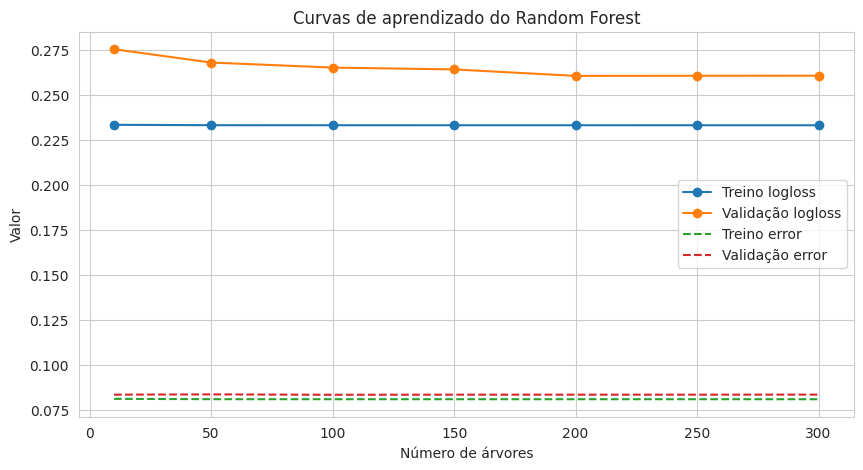

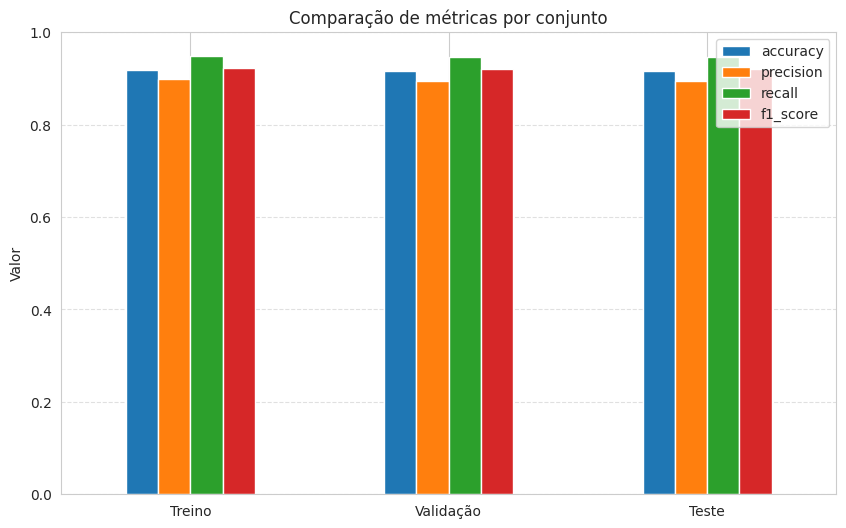

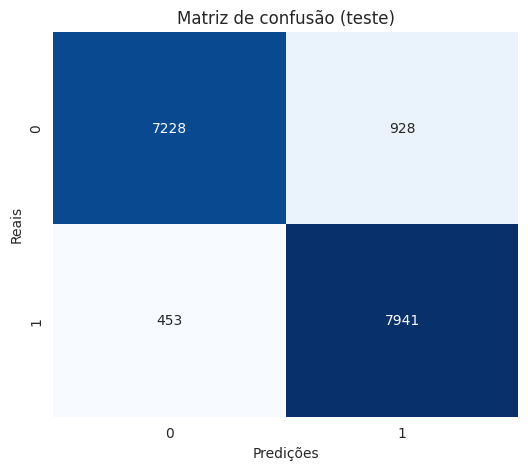

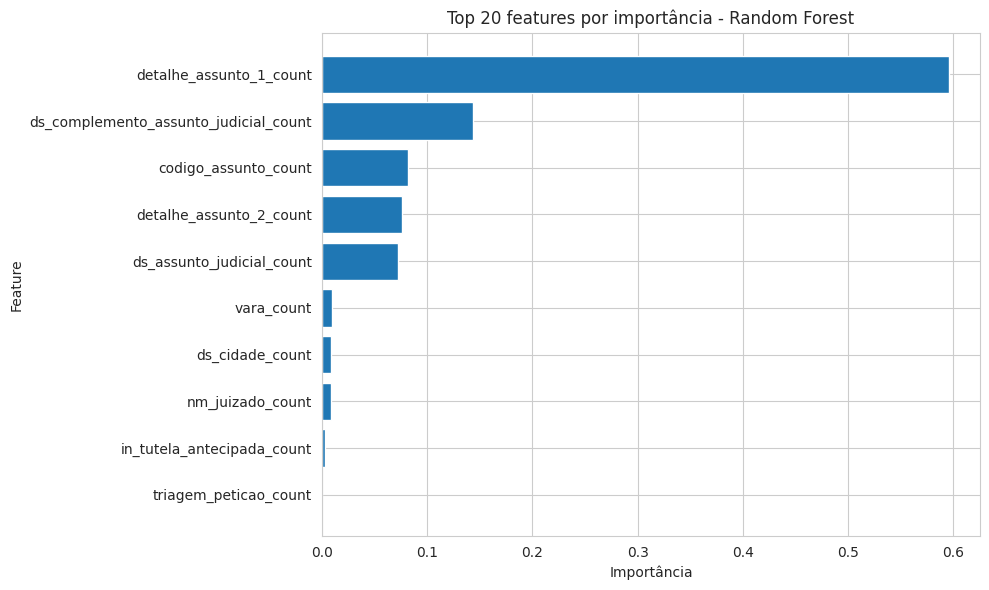

,feature,importance
6,detalhe_assunto_1_count,0.595490
5,ds_complemento_assunto_judicial_count,0.143773
3,codigo_assunto_count,0.081730
7,detalhe_assunto_2_count,0.075768
4,ds_assunto_judicial_count,0.072523
8,vara_count,0.009962
2,ds_cidade_count,0.009058
1,nm_juizado_count,0.008424
0,in_tutela_antecipada_count,0.003273
9,triagem_peticao_count,0.000000


In [9]:
# gráficos de evolução e desempenho

history_df = pd.DataFrame(learning_history)

plt.figure(figsize=(10, 5))
plt.plot(history_df['n_estimators'], history_df['train_logloss'], label='Treino logloss', marker='o')
plt.plot(history_df['n_estimators'], history_df['val_logloss'], label='Validação logloss', marker='o')
plt.plot(history_df['n_estimators'], history_df['train_error'], label='Treino error', linestyle='--')
plt.plot(history_df['n_estimators'], history_df['val_error'], label='Validação error', linestyle='--')
plt.xlabel('Número de árvores')
plt.ylabel('Valor')
plt.title('Curvas de aprendizado do Random Forest')
plt.legend()
plt.grid(True)
plt.show()

metrics_summary = {
    'Treino': compute_metrics(y_train, model.predict(X_train)),
    'Validação': compute_metrics(y_val, model.predict(X_val)),
    'Teste': compute_metrics(y_test, y_test_pred),
}
metrics_df = pd.DataFrame(metrics_summary).T
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparação de métricas por conjunto')
plt.ylim(0, 1)
plt.ylabel('Valor')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusão (teste)')
plt.xlabel('Predições')
plt.ylabel('Reais')
plt.show()

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_,
}).sort_values(by='importance', ascending=False).head(20)

feature_importance_plot = feature_importance.sort_values(by='importance', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_plot['feature'], feature_importance_plot['importance'])
plt.title('Top 20 features por importância - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

feature_importance

### Validação Cruzada (10-Fold)

Para uma avaliação mais robusta do modelo, vamos aplicar a validação cruzada com 10 folds estratificados. Isso ajuda a reduzir a variância da estimativa de desempenho do modelo, garantindo que cada fold mantenha a proporção das classes alvo, o que é especialmente útil para evitar avaliações dependentes de uma única divisão dos dados.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Inicializar o StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Listas para armazenar as métricas de cada fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print('Iniciando validação cruzada com 10 folds...')

# Iterar sobre cada fold
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f'\n--- Fold {fold+1}/10 ---')
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Re-inicializar o modelo para cada fold
    fold_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
    )

    # Treinar o modelo no fold atual
    fold_model.fit(X_train_fold, y_train_fold)

    # Fazer previsões no conjunto de validação do fold
    y_pred_fold = fold_model.predict(X_val_fold)

    # Calcular métricas e armazenar
    metrics = compute_metrics(y_val_fold, y_pred_fold)
    accuracy_scores.append(metrics['accuracy'])
    precision_scores.append(metrics['precision'])
    recall_scores.append(metrics['recall'])
    f1_scores.append(metrics['f1_score'])

    print(f'  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  Precision: {metrics["precision"]:.4f}')
    print(f'  Recall: {metrics["recall"]:.4f}')
    print(f'  F1-Score: {metrics["f1_score"]:.4f}')

print('\nValidação cruzada concluída.')

Iniciando validação cruzada com 10 folds...

--- Fold 1/10 ---
  Accuracy: 0.9147
  Precision: 0.8936
  Recall: 0.9444
  F1-Score: 0.9183

--- Fold 2/10 ---
  Accuracy: 0.9196
  Precision: 0.8998
  Recall: 0.9469
  F1-Score: 0.9227

--- Fold 3/10 ---
  Accuracy: 0.9227
  Precision: 0.9042
  Recall: 0.9479
  F1-Score: 0.9256

--- Fold 4/10 ---
  Accuracy: 0.9198
  Precision: 0.8976
  Recall: 0.9503
  F1-Score: 0.9232

--- Fold 5/10 ---
  Accuracy: 0.9150
  Precision: 0.8940
  Recall: 0.9444
  F1-Score: 0.9185

--- Fold 6/10 ---
  Accuracy: 0.9176
  Precision: 0.8988
  Recall: 0.9438
  F1-Score: 0.9207

--- Fold 7/10 ---
  Accuracy: 0.9140
  Precision: 0.8918
  Recall: 0.9450
  F1-Score: 0.9176

--- Fold 8/10 ---
  Accuracy: 0.9200
  Precision: 0.8998
  Recall: 0.9478
  F1-Score: 0.9232

--- Fold 9/10 ---
  Accuracy: 0.9147
  Precision: 0.8909
  Recall: 0.9479
  F1-Score: 0.9186

--- Fold 10/10 ---
  Accuracy: 0.9162
  Precision: 0.8959
  Recall: 0.9446
  F1-Score: 0.9196

Validação cruz


--- Métricas Médias da Validação Cruzada (10-Fold) ---
  Média Accuracy: 0.9174 (+/- 0.0028)
  Média Precision: 0.8966 (+/- 0.0039)
  Média Recall: 0.9463 (+/- 0.0021)
  Média F1-Score: 0.9208 (+/- 0.0026)


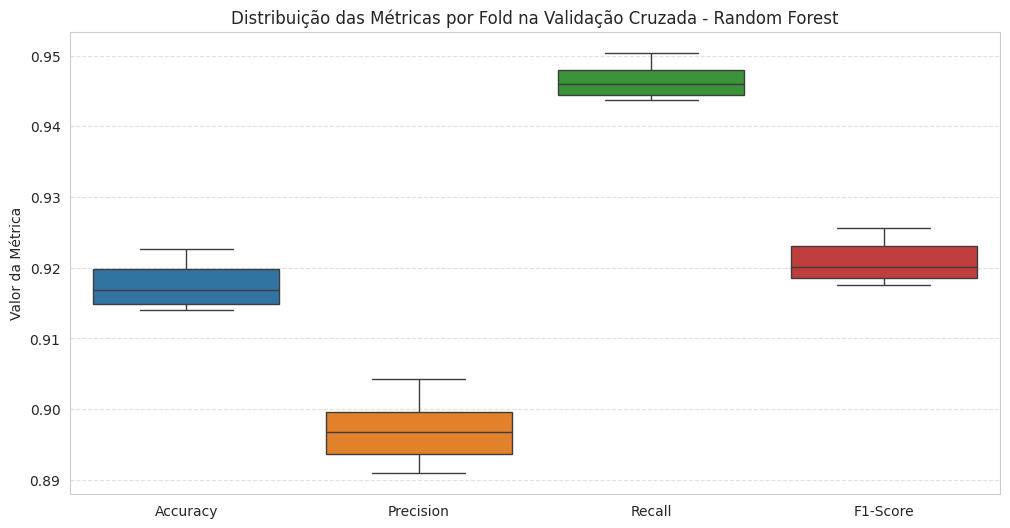

,Accuracy,Precision,Recall,F1-Score
count,10.000000,10.000000,10.000000,10.000000
mean,0.917431,0.896648,0.946294,0.920799
std,0.002947,0.004153,0.002180,0.002710
min,0.913958,0.890942,0.943769,0.917631
25%,0.914804,0.893687,0.944423,0.918504
50%,0.916916,0.896762,0.945914,0.920175
75%,0.919758,0.899547,0.947909,0.923072
max,0.922659,0.904205,0.950322,0.925555


In [ ]:
# Exibir as métricas médias da validação cruzada
print(f'\n--- Métricas Médias da Validação Cruzada (10-Fold) ---')
print(f'  Média Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})')
print(f'  Média Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})')
print(f'  Média Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})')
print(f'  Média F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})')

# Visualizar a distribuição das métricas por fold
metrics_df_cv = pd.DataFrame({
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores,
    'F1-Score': f1_scores
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=metrics_df_cv)
plt.title('Distribuição das Métricas por Fold na Validação Cruzada - Random Forest')
plt.ylabel('Valor da Métrica')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

metrics_df_cv.describe()

A validação cruzada com 10 folds reforça a estabilidade do classificador Random Forest nesse dataset. O modelo apresentou desempenho consistente entre treino, validação, teste e folds da validação cruzada, usando apenas as features mantidas antes da realização da perícia.